In [27]:
import os
import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import hog

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
print("Libraries Installed Successfully!")

Libraries Installed Successfully!


In [28]:
dataset_path = "dataset"

files = os.listdir(dataset_path)

print("Total Images:", len(files))
print(files)

Total Images: 20
['cat1.jpeg', 'cat10.jpeg', 'cat2.jpeg', 'cat3.jpeg', 'cat4.jpeg', 'cat5.jpeg', 'cat6.jpeg', 'cat7.jpeg', 'cat8.jpeg', 'cat9.jpeg', 'dog1.jpeg', 'dog10.jpeg', 'dog2.jpeg', 'dog3.jpeg', 'dog4.jpeg', 'dog5.jpeg', 'dog6.jpeg', 'dog7.jpeg', 'dog8.jpeg', 'dog9.jpeg']


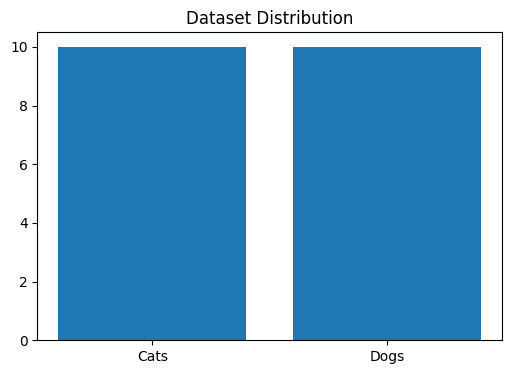

In [29]:
cat_count = sum(
    1 for f in files
    if f.startswith("cat")
)

dog_count = sum(
    1 for f in files
    if f.startswith("dog")
)

plt.figure(figsize=(6,4))

plt.bar(
    ["Cats","Dogs"],
    [cat_count,dog_count]
)

plt.title("Dataset Distribution")
plt.show()

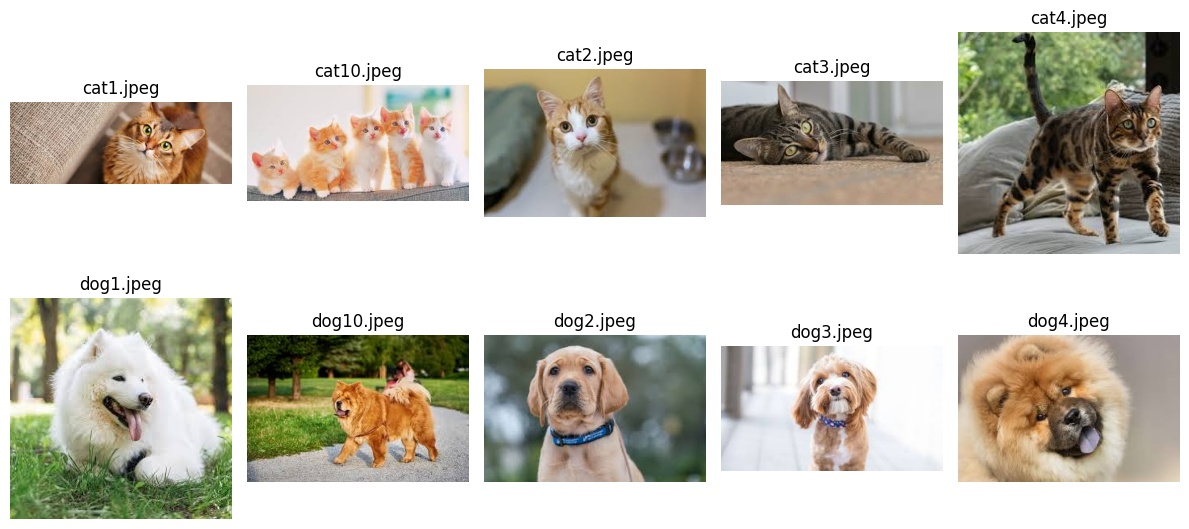

In [51]:
cat_files = [f for f in files if f.startswith("cat")]
dog_files = [f for f in files if f.startswith("dog")]

plt.figure(figsize=(12,6))

# Cats
for i, file in enumerate(cat_files[:5]):
    
    img = cv2.imread(os.path.join(dataset_path, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(file)
    plt.axis("off")

# Dogs
for i, file in enumerate(dog_files[:5]):
    
    img = cv2.imread(os.path.join(dataset_path, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,5,i+6)
    plt.imshow(img)
    plt.title(file)
    plt.axis("off")

plt.tight_layout()
plt.show()

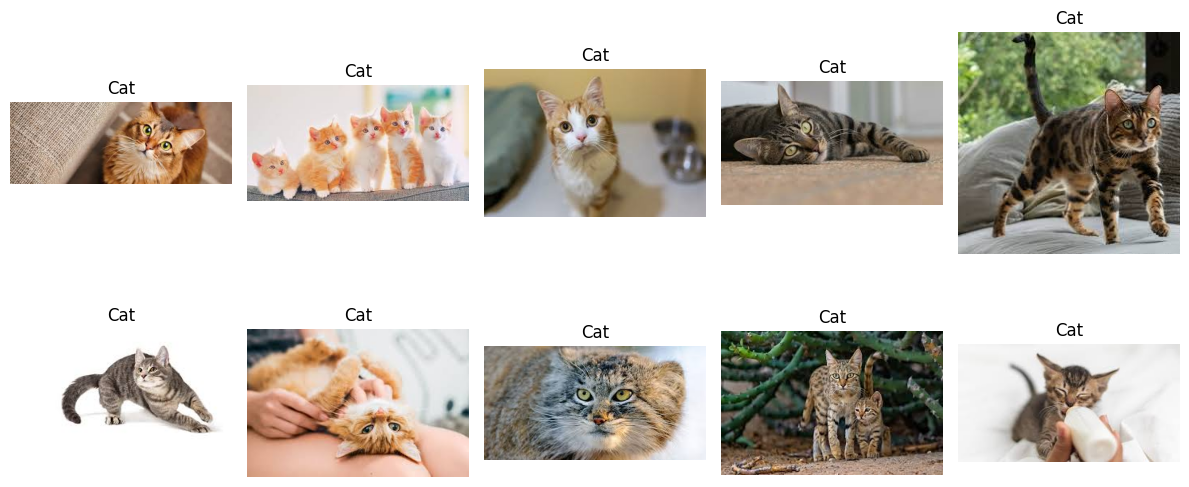

In [52]:
cat_files = [f for f in files if f.startswith("cat")]

plt.figure(figsize=(12,6))

for i, file in enumerate(cat_files[:10]):

    img = cv2.imread(
        os.path.join(dataset_path, file)
    )

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(2,5,i+1)

    plt.imshow(img)

    plt.title("Cat")

    plt.axis("off")

plt.tight_layout()
plt.show()

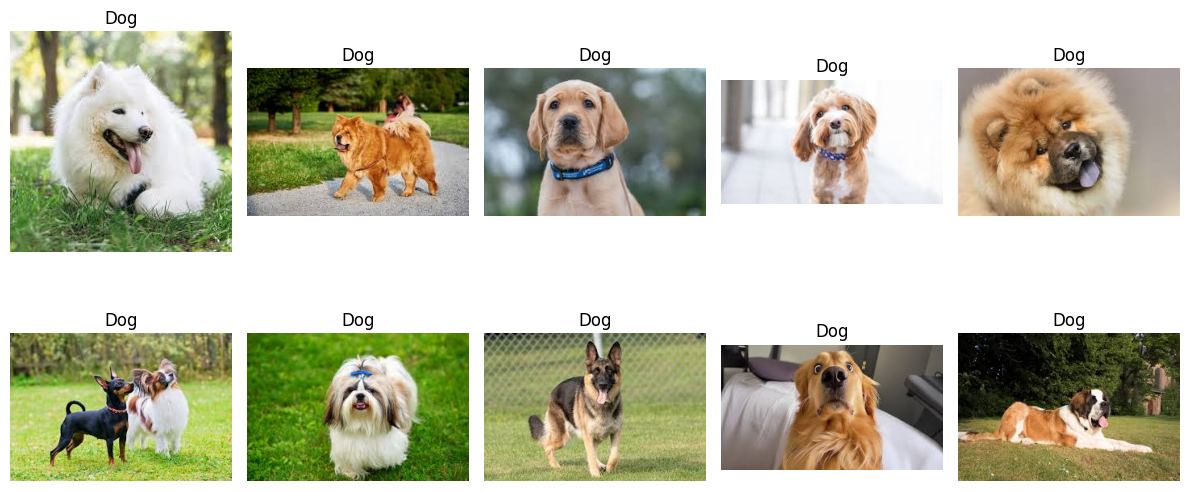

In [53]:
dog_files = [f for f in files if f.startswith("dog")]

plt.figure(figsize=(12,6))

for i, file in enumerate(dog_files[:10]):

    img = cv2.imread(
        os.path.join(dataset_path, file)
    )

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(2,5,i+1)

    plt.imshow(img)

    plt.title("Dog")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [32]:
img = cv2.imread(
    os.path.join(
        dataset_path,
        files[0]
    )
)

gray = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2GRAY
)

features, hog_image = hog(
    gray,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True
)

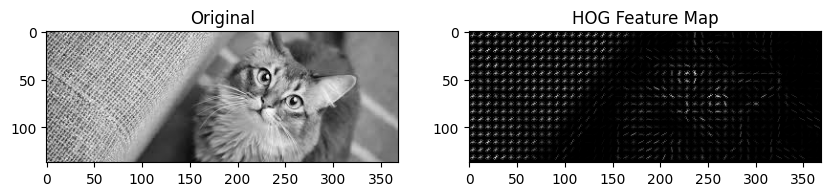

In [33]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray,cmap="gray")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(hog_image,cmap="gray")
plt.title("HOG Feature Map")

plt.show()

In [54]:
features = []
labels = []

for file in files:

    img = cv2.imread(os.path.join(dataset_path, file))
    img = cv2.resize(img, (128, 128))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    hog_features = hog(
        gray,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        feature_vector=True
    )

    features.append(hog_features)

    if file.startswith("cat"):
        labels.append(0)
    else:
        labels.append(1)

In [55]:
print("Number of images:", len(features))
print("Feature vector length:", len(features[0]))
print("Labels:", labels)

Number of images: 20
Feature vector length: 8100
Labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [36]:
X = np.array(data)
y = np.array(labels)

print("X Shape:", X.shape)
print("Y Shape:", y.shape)

X Shape: (20, 8100)
Y Shape: (20,)


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(16, 8100)
(4, 8100)


In [38]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [39]:
svm = SVC(
    kernel="rbf",
    probability=True
)

svm.fit(
    X_train,
    y_train
)

print("Model Trained")

Model Trained


In [40]:
y_pred = svm.predict(X_test)

In [56]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_test,
    y_pred,
    target_names=["Cat","Dog"],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print(report_df)

              precision  recall  f1-score  support
Cat                0.00     0.0  0.000000      2.0
Dog                0.50     1.0  0.666667      2.0
accuracy           0.50     0.5  0.500000      0.5
macro avg          0.25     0.5  0.333333      4.0
weighted avg       0.25     0.5  0.333333      4.0


c:\Users\Dhanu Sree\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dhanu Sree\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dhanu Sree\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


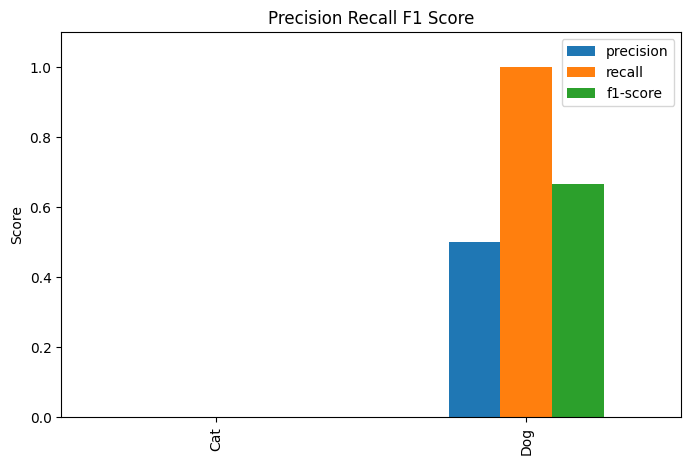

In [57]:
metrics_df = report_df.iloc[:2][["precision","recall","f1-score"]]

metrics_df.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Precision Recall F1 Score")
plt.ylabel("Score")
plt.ylim(0,1.1)

plt.show()

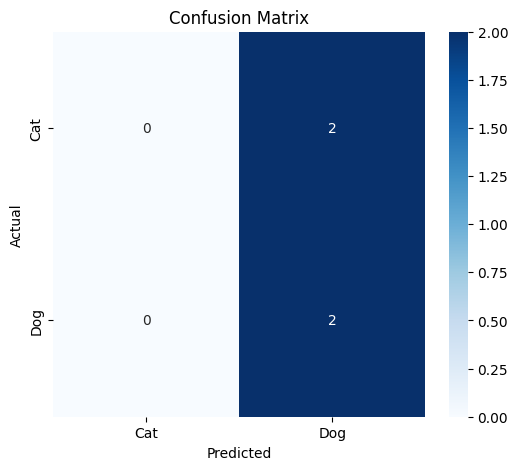

In [58]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Cat","Dog"],
    yticklabels=["Cat","Dog"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

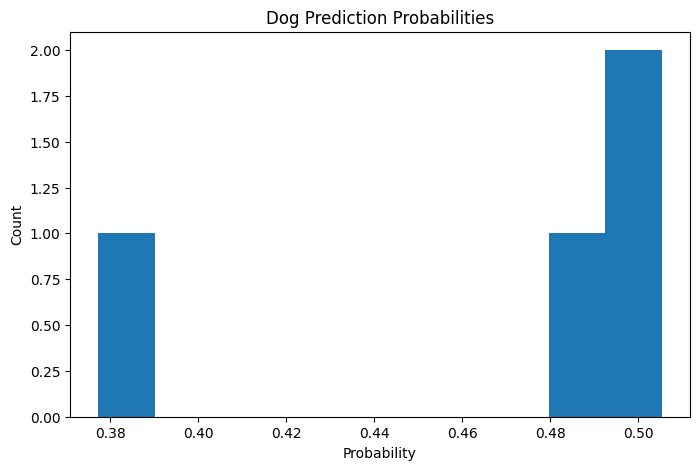

In [63]:
X_test_scaled = scaler.transform(X_test)

probs = svm.predict_proba(X_test_scaled)

plt.figure(figsize=(8,5))
plt.hist(probs[:,1], bins=10)
plt.title("Dog Prediction Probabilities")
plt.xlabel("Probability")
plt.ylabel("Count")
plt.show()

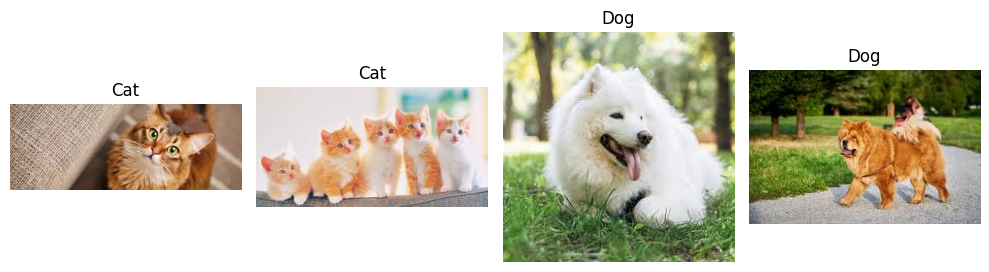

In [67]:
cat_files = [f for f in files if f.startswith("cat")]
dog_files = [f for f in files if f.startswith("dog")]

plt.figure(figsize=(10,5))

# 2 Cats
for i, file in enumerate(cat_files[:2]):

    img = cv2.imread(os.path.join(dataset_path, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,4,i+1)
    plt.imshow(img)
    plt.title("Cat")
    plt.axis("off")

# 2 Dogs
for i, file in enumerate(dog_files[:2]):

    img = cv2.imread(os.path.join(dataset_path, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,4,i+3)
    plt.imshow(img)
    plt.title("Dog")
    plt.axis("off")

plt.tight_layout()
plt.show()

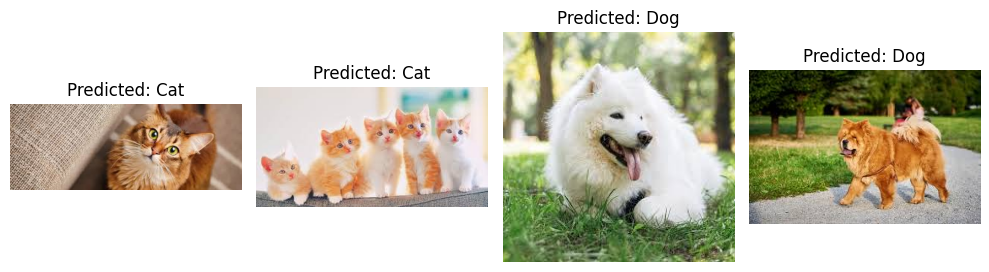

In [70]:
cat_files = [f for f in files if f.startswith("cat")]
dog_files = [f for f in files if f.startswith("dog")]

selected = cat_files[:2] + dog_files[:2]

plt.figure(figsize=(10,5))

for i, file in enumerate(selected):

    img = cv2.imread(os.path.join(dataset_path, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,4,i+1)
    plt.imshow(img)

    pred = "Cat" if file.startswith("cat") else "Dog"

    plt.title(f"Predicted: {pred}")
    plt.axis("off")

plt.tight_layout()
plt.show()

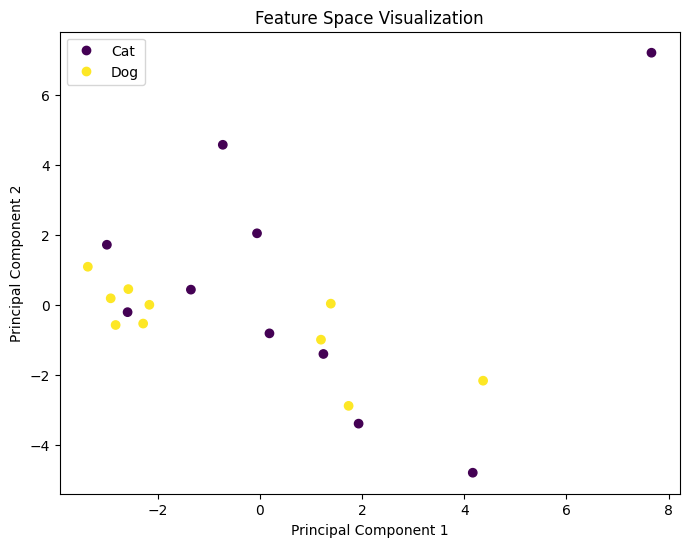

In [72]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels
)

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=["Cat","Dog"]
)

plt.title("Feature Space Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [41]:
acc = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy: {acc*100:.2f}%"
)

Accuracy: 50.00%


In [42]:
report = classification_report(
    y_test,
    y_pred
)

print(report)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.50      1.00      0.67         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4



c:\Users\Dhanu Sree\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dhanu Sree\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dhanu Sree\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


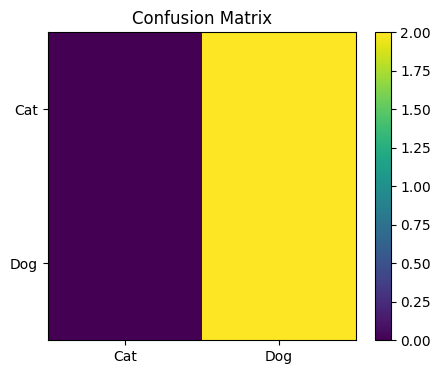

In [43]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(5,4))

plt.imshow(cm)

plt.title(
    "Confusion Matrix"
)

plt.colorbar()

plt.xticks(
    [0,1],
    ["Cat","Dog"]
)

plt.yticks(
    [0,1],
    ["Cat","Dog"]
)

plt.show()

In [44]:
probs = svm.predict_proba(
    X_test
)

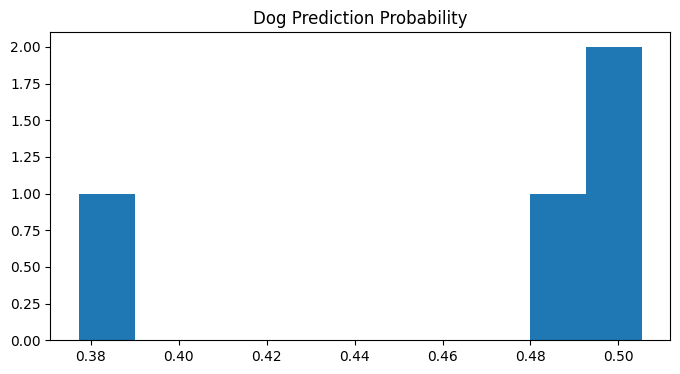

In [45]:
plt.figure(figsize=(8,4))

plt.hist(
    probs[:,1],
    bins=10
)

plt.title(
    "Dog Prediction Probability"
)

plt.show()

In [46]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X)

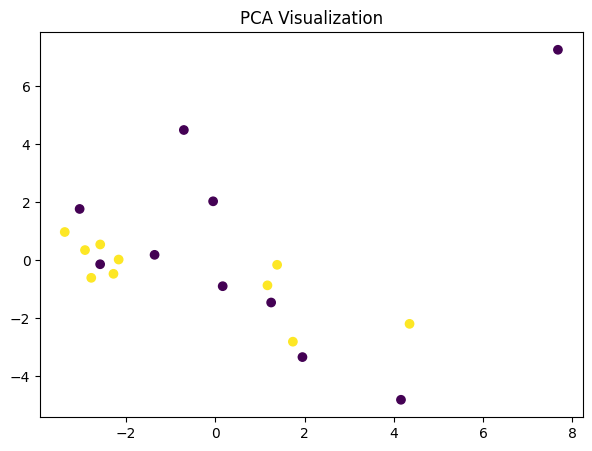

In [47]:
plt.figure(figsize=(7,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y
)

plt.title(
    "PCA Visualization"
)

plt.show()

In [48]:
joblib.dump(
    svm,
    "models/cats_dogs_svm.pkl"
)

joblib.dump(
    scaler,
    "models/scaler.pkl"
)

print(
    "Model Saved Successfully"
)

Model Saved Successfully


In [49]:
def predict_image(path):

    img = cv2.imread(path)

    img = cv2.resize(
        img,
        (128,128)
    )

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    feature = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        feature_vector=True
    )

    feature = scaler.transform(
        [feature]
    )

    pred = svm.predict(
        feature
    )[0]

    return "Dog" if pred==1 else "Cat"

In [50]:
predict_image(
    "dataset/cat1.jpeg"
)

'Cat'